# Dense Retrieval Benchmark

**FAISS vs ChromaDB vs Qdrant vs Pinecone** on BEIR/SciFact

This code builds a dense retrieval pipeline over the **BEIR/SciFact** dataset using a single sentence-transformer embedding model. It indexes the same embeddings into **four vector databases**:

- **FAISS**: in-memory
- **ChromaDB**: persistent, indexed
- **Qdrant**: in-memory (using qdrant-client)
- **Pinecone**: managed cloud vector DB (requires an API key)


Values to compare:
- **Retrieval speed** (indexing time, total query time, mean query latency, queries/sec)
- **NDCG@10**
- **MRR@10**
- **Precision@10**



**Notes:**
All metrics are calculated using the official SciFact qrels using pytrec_eval (via BEIR's evaluation module), so every backend is scored on identical ground truth.

Pinecone requires a [Pinecone API key](https://app.pinecone.io).


## Install dependencies

In [ ]:
!pip install -q beir chromadb faiss-cpu sentence-transformers pytrec_eval qdrant-client pinecone


  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.4/77.4 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 54.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 67.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 396.2/396.2 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 45.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 74.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 51.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.2/137.2 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━

## Imports

In [ ]:
import os
import time
import json
import getpass
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from beir import util, LoggingHandler
from beir.datasets.data_loader import GenericDataLoader
from beir.retrieval.evaluation import EvaluateRetrieval

from sentence_transformers import SentenceTransformer
import faiss
import chromadb

from qdrant_client import QdrantClient
from qdrant_client.models import Distance, VectorParams, PointStruct

from pinecone import Pinecone, ServerlessSpec

import logging
logging.basicConfig(format='%(asctime)s - %(message)s', datefmt='%Y-%m-%d %H:%M:%S', level=logging.INFO, handlers=[LoggingHandler()])


/usr/local/lib/python3.12/dist-packages/beir/util.py:11: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


## Load the BEIR/SciFact dataset

SciFact is a fact-verification / scientific claim retrieval datase. The queries are scientific claims, the corpus is scientific abstracts, and qrels mark which abstracts support/refute each claim. The standard `test` split is used, which is what BEIR's leaderboard evaluates on.

In [ ]:
dataset = "scifact"
url = f"https://public.ukp.informatik.tu-darmstadt.de/thakur/BEIR/datasets/{dataset}.zip"
out_dir = os.path.join(os.getcwd(), "datasets")
data_path = util.download_and_unzip(url, out_dir)

corpus, queries, qrels = GenericDataLoader(data_folder=data_path).load(split="test")

print(f"Corpus size : {len(corpus)}")
print(f"Queries     : {len(queries)}")
print(f"Qrels (queries with judgments): {len(qrels)}")


/content/datasets/scifact.zip:   0%|          | 0.00/2.69M [00:00<?, ?iB/s]

  0%|          | 0/5183 [00:00<?, ?it/s]

Corpus size : 5183
Queries     : 300
Qrels (queries with judgments): 300


## Prepare corpus text and embedding model

Using the content `title` + `text` for each document (standard BEIR convention) the `sentence-transformers/all-MiniLM-L6-v2` is used as a fast, strong general-purpose dense encoder that's a common baseline for BEIR benchmarking.

In [ ]:
MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
model = SentenceTransformer(MODEL_NAME)

corpus_ids = list(corpus.keys())
corpus_texts = [
    (corpus[cid].get("title", "") + " " + corpus[cid].get("text", "")).strip()
    for cid in corpus_ids
]

query_ids = list(queries.keys())
query_texts = [queries[qid] for qid in query_ids]

print(f"Embedding model : {MODEL_NAME}")
print(f"Corpus docs     : {len(corpus_texts)}")
print(f"Queries         : {len(query_texts)}")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding model : sentence-transformers/all-MiniLM-L6-v2
Corpus docs     : 5183
Queries         : 300


## Encode corpus and queries

Embeddings are computed **once** and reused across all four backends.

In [ ]:
BATCH_SIZE = 64
TOP_K = 10

t0 = time.time()
corpus_embeddings = model.encode(
    corpus_texts, batch_size=BATCH_SIZE, show_progress_bar=True, convert_to_numpy=True
)
encoding_time = time.time() - t0

faiss.normalize_L2(corpus_embeddings)  # in-place cosine normalization
corpus_embeddings = corpus_embeddings.astype("float32")

query_embeddings = model.encode(
    query_texts, batch_size=BATCH_SIZE, show_progress_bar=True, convert_to_numpy=True
)
faiss.normalize_L2(query_embeddings)
query_embeddings = query_embeddings.astype("float32")

embedding_dim = corpus_embeddings.shape[1]
print(f"Corpus embedding time: {encoding_time:.2f}s")
print(f"Embedding dimension  : {embedding_dim}")


Batches:   0%|          | 0/81 [00:00<?, ?it/s]

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

Corpus embedding time: 16.82s
Embedding dimension  : 384


## Utility functions

Every backend returns the same JSON: a `results` dict (`{qid: {docid: score}}`) that has timing stats, appended to a shared `backend_stats` dict to evaluate and compare all of them identically.

In [ ]:
backend_stats = {}  # name -> {"index_time", "results", "query_times", "total_query_time"}

def record_backend(name, index_time, results, query_times, total_query_time):
    backend_stats[name] = {
        "index_time": index_time,
        "results": results,
        "mean_latency_ms": float(np.mean(query_times) * 1000),
        "total_query_time": total_query_time,
        "qps": len(query_times) / total_query_time,
    }
    print(f"[{name}] index build: {index_time:.4f}s | total query: {total_query_time:.4f}s | "
          f"mean latency: {backend_stats[name]['mean_latency_ms']:.3f} ms | qps: {backend_stats[name]['qps']:.1f}")


## Vector Stores

### FAISS

In [ ]:
t0 = time.time()
faiss_index = faiss.IndexFlatIP(embedding_dim)
faiss_index.add(corpus_embeddings)
faiss_index_time = time.time() - t0

faiss_query_times = []
faiss_results = {}

t_total0 = time.time()
for i, qid in enumerate(query_ids):
    q_emb = query_embeddings[i:i+1]
    t_q0 = time.time()
    scores, indices = faiss_index.search(q_emb, TOP_K)
    faiss_query_times.append(time.time() - t_q0)

    doc_scores = {}
    for rank in range(TOP_K):
        idx = indices[0][rank]
        if idx == -1:
            continue
        doc_scores[corpus_ids[idx]] = float(scores[0][rank])
    faiss_results[qid] = doc_scores
faiss_total_query_time = time.time() - t_total0

record_backend("FAISS", faiss_index_time, faiss_results, faiss_query_times, faiss_total_query_time)


[FAISS] index build: 0.0036s | total query: 0.1085s | mean latency: 0.344 ms | qps: 2764.0


### ChromaDB

In [ ]:
chroma_client = chromadb.PersistentClient(path="./chroma_scifact_db")

try:
    chroma_client.delete_collection("scifact_dense")
except Exception:
    pass

chroma_collection = chroma_client.create_collection(
    name="scifact_dense",
    metadata={"hnsw:space": "cosine"}
)

CHROMA_BATCH = 512
t0 = time.time()
for start in range(0, len(corpus_ids), CHROMA_BATCH):
    end = start + CHROMA_BATCH
    chroma_collection.add(
        ids=corpus_ids[start:end],
        embeddings=corpus_embeddings[start:end].tolist(),
    )
chroma_index_time = time.time() - t0

chroma_query_times = []
chroma_results = {}

t_total0 = time.time()
for i, qid in enumerate(query_ids):
    q_emb = query_embeddings[i].tolist()
    t_q0 = time.time()
    res = chroma_collection.query(query_embeddings=[q_emb], n_results=TOP_K)
    chroma_query_times.append(time.time() - t_q0)

    doc_scores = {}
    for doc_id, dist in zip(res["ids"][0], res["distances"][0]):
        doc_scores[doc_id] = float(1 - dist)  # cosine similarity = 1 - cosine distance
    chroma_results[qid] = doc_scores
chroma_total_query_time = time.time() - t_total0

record_backend("ChromaDB", chroma_index_time, chroma_results, chroma_query_times, chroma_total_query_time)


[ChromaDB] index build: 1.8650s | total query: 0.5074s | mean latency: 1.662 ms | qps: 591.2


### Qdrant


In [ ]:
qdrant_client = QdrantClient(location=":memory:")

COLLECTION_NAME = "scifact_dense"
if qdrant_client.collection_exists(COLLECTION_NAME):
    qdrant_client.delete_collection(COLLECTION_NAME)
qdrant_client.create_collection(
    collection_name=COLLECTION_NAME,
    vectors_config=VectorParams(size=embedding_dim, distance=Distance.COSINE),
)

QDRANT_BATCH = 512
t0 = time.time()
for start in range(0, len(corpus_ids), QDRANT_BATCH):
    end = min(start + QDRANT_BATCH, len(corpus_ids))
    points = [
        PointStruct(id=idx, vector=corpus_embeddings[idx].tolist(), payload={"doc_id": corpus_ids[idx]})
        for idx in range(start, end)
    ]
    qdrant_client.upsert(collection_name=COLLECTION_NAME, points=points)
qdrant_index_time = time.time() - t0

qdrant_query_times = []
qdrant_results = {}

t_total0 = time.time()
for i, qid in enumerate(query_ids):
    q_emb = query_embeddings[i].tolist()
    t_q0 = time.time()
    response = qdrant_client.query_points(collection_name=COLLECTION_NAME, query=q_emb, limit=TOP_K, with_payload=True)
    qdrant_query_times.append(time.time() - t_q0)

    doc_scores = {hit.payload["doc_id"]: float(hit.score) for hit in response.points}
    qdrant_results[qid] = doc_scores
qdrant_total_query_time = time.time() - t_total0

record_backend("Qdrant", qdrant_index_time, qdrant_results, qdrant_query_times, qdrant_total_query_time)


[Qdrant] index build: 4.4279s | total query: 3.3288s | mean latency: 11.054 ms | qps: 90.1


### Pinecone

Prompt for API key ([app.pinecone.io](https://app.pinecone.io))

In [ ]:
PINECONE_API_KEY = getpass.getpass("Enter your Pinecone API key (or press Enter to skip Pinecone): ").strip()

if PINECONE_API_KEY:
    pc = Pinecone(api_key=PINECONE_API_KEY)
    PINECONE_INDEX_NAME = "beir-scifact-dense"

    existing = [idx["name"] for idx in pc.list_indexes()]
    if PINECONE_INDEX_NAME in existing:
        pc.delete_index(PINECONE_INDEX_NAME)
        time.sleep(2)

    pc.create_index(
        name=PINECONE_INDEX_NAME,
        dimension=embedding_dim,
        metric="cosine",
        spec=ServerlessSpec(cloud="aws", region="us-east-1"),
    )
    # Wait for the index to report ready before writing to it
    while not pc.describe_index(PINECONE_INDEX_NAME).status["ready"]:
        time.sleep(1)

    pinecone_index = pc.Index(PINECONE_INDEX_NAME)

    PINECONE_BATCH = 100  # Pinecone recommends <=100 vectors per upsert call
    t0 = time.time()
    for start in range(0, len(corpus_ids), PINECONE_BATCH):
        end = min(start + PINECONE_BATCH, len(corpus_ids))
        vectors = [
            (corpus_ids[idx], corpus_embeddings[idx].tolist())
            for idx in range(start, end)
        ]
        pinecone_index.upsert(vectors=vectors)
    # Serverless upserts are eventually consistent - brief wait so queries see all vectors
    time.sleep(5)
    pinecone_index_time = time.time() - t0

    pinecone_query_times = []
    pinecone_results = {}

    t_total0 = time.time()
    for i, qid in enumerate(query_ids):
        q_emb = query_embeddings[i].tolist()
        t_q0 = time.time()
        res = pinecone_index.query(vector=q_emb, top_k=TOP_K, include_values=False)
        pinecone_query_times.append(time.time() - t_q0)

        doc_scores = {match["id"]: float(match["score"]) for match in res["matches"]}
        pinecone_results[qid] = doc_scores
    pinecone_total_query_time = time.time() - t_total0

    record_backend("Pinecone", pinecone_index_time, pinecone_results, pinecone_query_times, pinecone_total_query_time)

    # Clean up the cloud index so it doesn't keep running/costing after the notebook finishes
    pc.delete_index(PINECONE_INDEX_NAME)
else:
    print("No API key entered - skipping Pinecone. It will be excluded from the comparison below.")


Enter your Pinecone API key (or press Enter to skip Pinecone): ··········
[Pinecone] index build: 18.8666s | total query: 22.9669s | mean latency: 76.505 ms | qps: 13.1


## Evaluation

Evaluation against qrels: NDCG@10, MRR@10, Precision@10


In [ ]:
evaluator = EvaluateRetrieval()
K_VALUES = [1, 5, 10]

def score_backend(results):
    ndcg, _map, recall, precision = evaluator.evaluate(qrels, results, K_VALUES)
    mrr = evaluator.evaluate_custom(qrels, results, K_VALUES, metric="mrr")
    return {
        "NDCG@10": ndcg["NDCG@10"],
        "MRR@10": mrr["MRR@10"],
        "Precision@10": precision["P@10"],
        "Recall@10": recall["Recall@10"],
    }

for name, stats in backend_stats.items():
    stats["scores"] = score_backend(stats["results"])
    print(f"{name:10s}: {stats['scores']}")


FAISS     : {'NDCG@10': 0.64508, 'MRR@10': 0.60472, 'Precision@10': 0.08833, 'Recall@10': 0.78333}
ChromaDB  : {'NDCG@10': 0.64175, 'MRR@10': 0.60139, 'Precision@10': 0.088, 'Recall@10': 0.78}
Qdrant    : {'NDCG@10': 0.64508, 'MRR@10': 0.60472, 'Precision@10': 0.08833, 'Recall@10': 0.78333}
Pinecone  : {'NDCG@10': 0.64498, 'MRR@10': 0.60461, 'Precision@10': 0.08833, 'Recall@10': 0.78333}


## Summary

In [ ]:
rows = []
for name, stats in backend_stats.items():
    rows.append({
        "Backend": name,
        "Index build (s)": round(stats["index_time"], 4),
        "Total query time (s)": round(stats["total_query_time"], 4),
        "Mean latency (ms/query)": round(stats["mean_latency_ms"], 3),
        "Throughput (q/s)": round(stats["qps"], 1),
        "NDCG@10": round(stats["scores"]["NDCG@10"], 4),
        "MRR@10": round(stats["scores"]["MRR@10"], 4),
        "Precision@10": round(stats["scores"]["Precision@10"], 4),
    })

summary = pd.DataFrame(rows)
summary


,Backend,Index build (s),Total query time (s),Mean latency (ms/query),Throughput (q/s),NDCG@10,MRR@10,Precision@10
0,FAISS,0.0036,0.1085,0.344,2764.0,0.6451,0.6047,0.0883
1,ChromaDB,1.8650,0.5074,1.662,591.2,0.6418,0.6014,0.0880
2,Qdrant,4.4279,3.3288,11.054,90.1,0.6451,0.6047,0.0883
3,Pinecone,18.8666,22.9669,76.505,13.1,0.6450,0.6046,0.0883


## Visual comparison

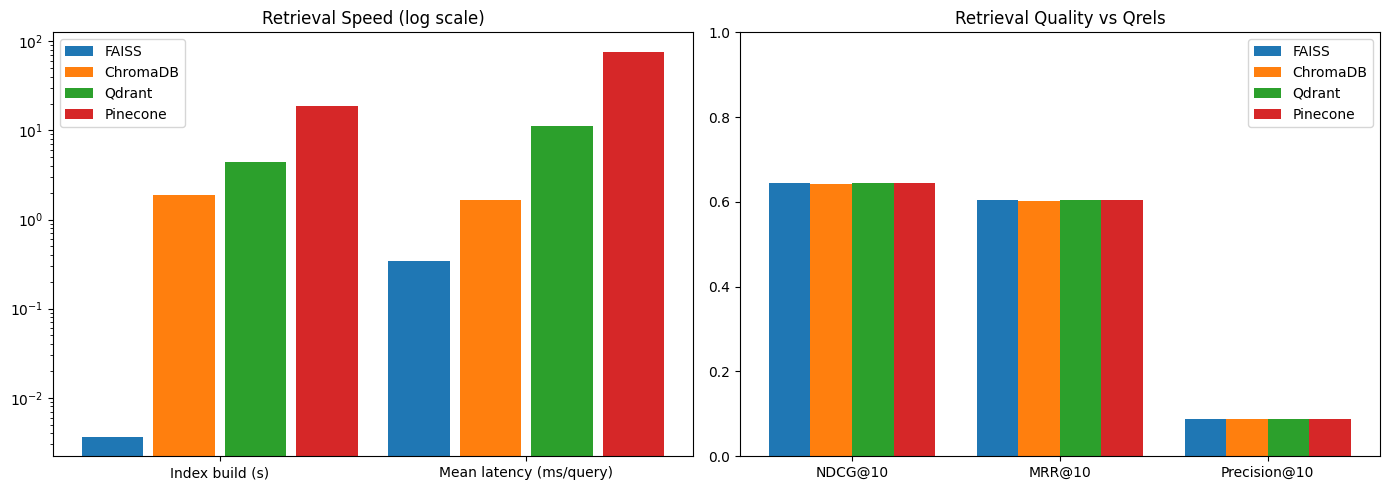

In [ ]:
names = list(backend_stats.keys())
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Speed comparison (log scale - Pinecone's network overhead can dwarf local backends)
width = 0.35
x = np.arange(2)
speed_labels = ["Index build (s)", "Mean latency (ms/query)"]
for i, name in enumerate(names):
    stats = backend_stats[name]
    offset = (i - (len(names) - 1) / 2) * (width / max(len(names) - 1, 1) * 2 if len(names) > 1 else 0)
    axes[0].bar(x + offset, [stats["index_time"], stats["mean_latency_ms"]],
                width=0.8 / len(names), label=name)
axes[0].set_xticks(x)
axes[0].set_xticklabels(speed_labels)
axes[0].set_yscale("log")
axes[0].set_title("Retrieval Speed (log scale)")
axes[0].legend()

# Quality comparison
quality_labels = ["NDCG@10", "MRR@10", "Precision@10"]
x2 = np.arange(len(quality_labels))
for i, name in enumerate(names):
    stats = backend_stats[name]
    vals = [stats["scores"][k] for k in quality_labels]
    offset = (i - (len(names) - 1) / 2) * (0.8 / len(names))
    axes[1].bar(x2 + offset, vals, width=0.8 / len(names), label=name)
axes[1].set_xticks(x2)
axes[1].set_xticklabels(quality_labels)
axes[1].set_ylim(0, 1)
axes[1].set_title("Retrieval Quality vs Qrels")
axes[1].legend()

plt.tight_layout()
plt.show()
